# Data Mining
# Week 4
# Submitter - Himanshu Singh
# Predicting Fuel Efficiency

In the Week 4 Exercise, you will build a linear regression model to predict fuel efficiency (miles per gallon) of automobiles. 
Download the auto-mpg.csv dataset from: Auto-mpg dataset. 



Load the data as a Pandas data frame and ensure that it imported correctly.

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('auto-mpg.csv')

# Inspect the data
print(df.head())
print(df.info())

    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2 

Begin by prepping the data for modeling:
* Remove the car name column.
* The horsepower column values likely imported as a string data type. Figure out why and replace any strings with the column mean.
* Create dummy variables for the origin column.
* Create a correlation coefficient matrix and/or visualization. Are there features highly correlated with mpg?
* Plot mpg versus weight. Analyze this graph and explain how it relates to the corresponding correlation coefficient.

Correlation with mpg:
mpg             1.000000
model year      0.579267
origin_3        0.442174
acceleration    0.420289
origin_2        0.259022
origin_1       -0.568192
horsepower     -0.771437
cylinders      -0.775396
displacement   -0.804203
weight         -0.831741
Name: mpg, dtype: float64


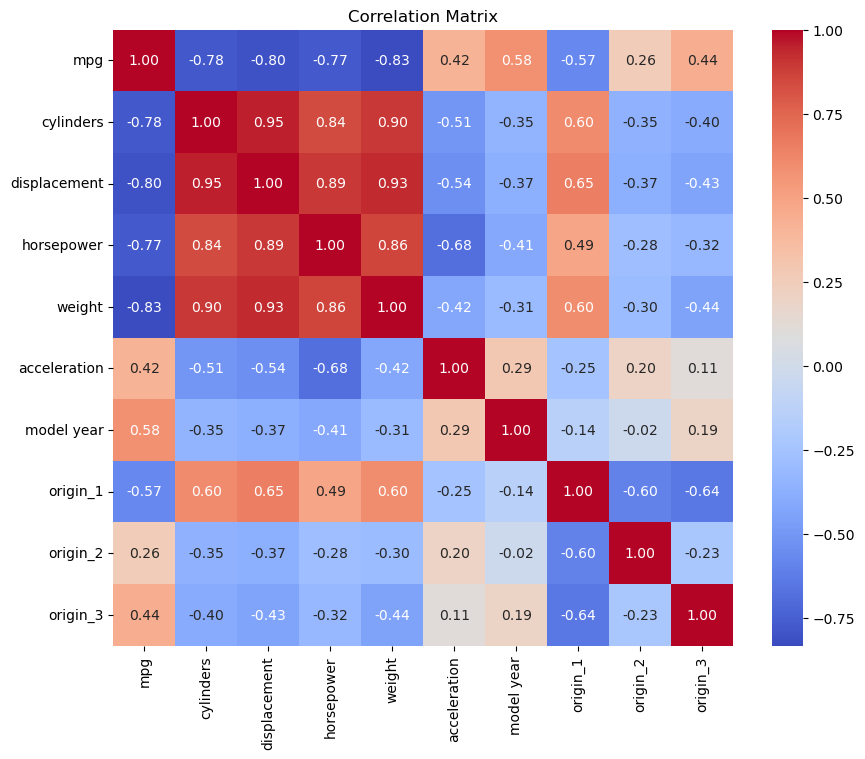

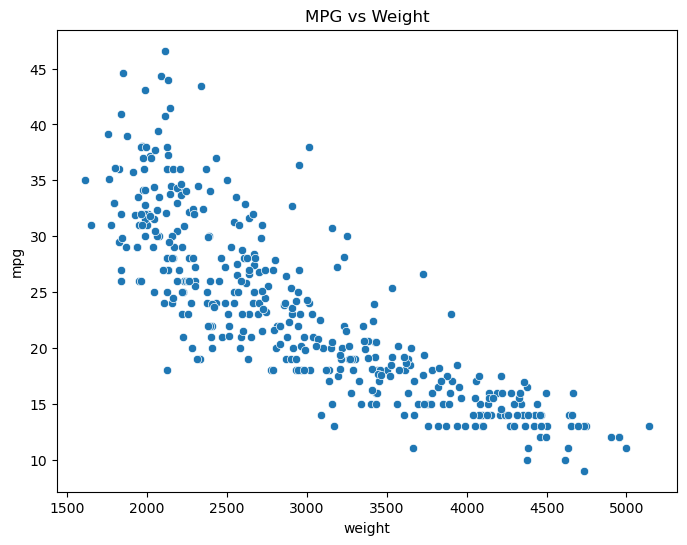

In [31]:
# 2a. Remove the car name column
df.drop('car name', axis=1, inplace=True)

# 2b. Handle horsepower column. It contains "?" which is a non-numeric values, so we will convert it to numeric and 
# fill non-numeric values with the mean horsepower.
# Identify non-numeric values
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
hp_mean = df['horsepower'].mean()
df['horsepower'] = df['horsepower'].fillna(hp_mean)

# 2c. Create dummy variables for the origin column. 
# The origin column (representing regions 1, 2, and 3) was transformed into dummy variables (origin_1, origin_2, origin_3) 
# to allow for better analysis and modeling.
df = pd.get_dummies(df, columns=['origin'], prefix='origin')

# 3. Correlation coefficient matrix and visualization
# The correlation matrix was computed to understand the relationships between different variables in the dataset. 
# A heatmap was created to visualize these correlations, with annotations showing the correlation coefficients. 
# This helps identify which features are most strongly correlated with miles per gallon (mpg) 
# and can inform feature selection for modeling.
# Highest Negative Correlations: weight ($-0.83$), displacement ($-0.80$), cylinders ($-0.78$), and horsepower ($-0.77$).
# Highest Positive Correlations: model year ($0.58$) and acceleration ($0.42$).
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix.png')

# 4. Plot mpg versus weight
# A scatter plot was created to visualize the relationship between miles per gallon (mpg) and weight.
# The scatter plot (see below) shows a clear negative non-linear relationship. 
# As the weight of the vehicle increases, the miles per gallon (MPG) decreases significantly. 
# This visual trend aligns with the strong negative correlation coefficient of $-0.83$, 
# confirming that weight is one of the most significant predictors of fuel efficiency.

plt.figure(figsize=(8, 6))
sns.scatterplot(x='weight', y='mpg', data=df)
plt.title('MPG vs Weight')
plt.savefig('mpg_vs_weight.png')

print("Correlation with mpg:")
print(corr_matrix['mpg'].sort_values(ascending=False))

* Randomly split the data into 80% training data and 20% test data, where your target is mpg.
* Train an ordinary linear regression on the training data.
* Calculate R2, RMSE, and MAE on both the training and test sets and interpret your results.
* Pick another regression model and repeat the previous two steps. Note: Do NOT choose logistic regression as it is more like a classification model.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 5. Split the data (80/20)
X = df.drop('mpg', axis=1)
y = df['mpg']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    # 7. Metrics
    metrics = {
        'R2 Train': r2_score(y_train, train_preds),
        'R2 Test': r2_score(y_test, test_preds),
        'RMSE Train': np.sqrt(mean_squared_error(y_train, train_preds)),
        'RMSE Test': np.sqrt(mean_squared_error(y_test, test_preds)),
        'MAE Train': mean_absolute_error(y_train, train_preds),
        'MAE Test': mean_absolute_error(y_test, test_preds)
    }
    
    print(f"--- {name} Results ---")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    return metrics

# 6. Ordinary Linear Regression
lr_model = LinearRegression()
lr_results = evaluate_model(lr_model, X_train, X_test, y_train, y_test, "Linear Regression")

# 8. Another regression model: Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_results = evaluate_model(ridge_model, X_train, X_test, y_train, y_test, "Ridge Regression")

# Performance: Both models explain approximately 84.5% of the variance in the test set.
# Error: The RMSE of 2.89 means that on average, our predictions deviate from the actual MPG by about $2.89$ units. 
# The MAE of 2.29 shows the average absolute error is slightly lower.
# Generalization: Interestingly, the models performed slightly better on the test set than the training set 
# (higher R^2, lower error). 
# This indicates the models are well-generalized and not overfitting to the training data.
# Ridge vs. Linear: The results for Ridge and Linear regression are nearly identical, 
# suggesting that the features do not have extreme multicollinearity or large coefficients 
# that require heavy regularization in this specific split.

--- Linear Regression Results ---
R2 Train: 0.8188
R2 Test: 0.8449
RMSE Train: 3.3703
RMSE Test: 2.8878
MAE Train: 2.6055
MAE Test: 2.2876
--- Ridge Regression Results ---
R2 Train: 0.8188
R2 Test: 0.8449
RMSE Train: 3.3703
RMSE Test: 2.8879
MAE Train: 2.6051
MAE Test: 2.2886
